# Lesson 3.3 — Mesh Generation

## The Map Analogy

A mesh is a map of the fluid domain. Just as a map must cover the territory without gaps
or overlaps, a mesh must cover the fluid volume with non-overlapping cells. The challenge:
physical domains are curved, irregular, and multi-scale. Good meshing is 40-60% of the
work in a real CFD project.

---

## Structured vs Unstructured Meshes

### Structured Mesh

Grid points arranged in a regular $i$-$j$-$k$ index space. Each point has exactly the same
number of neighbours. Examples: Cartesian grids, body-fitted grids.

**Pros**: fast indexing, cache-friendly, high-order schemes are easier.  
**Cons**: hard to fit complex geometries; requires structured topology.

### Unstructured Mesh

Cells of arbitrary shape (triangles, quads in 2D; tetrahedra, hexahedra in 3D) connected
via a connectivity table. No regular index structure.

**Pros**: fits any geometry; automatic refinement where needed.  
**Cons**: lower cache efficiency; more complex data structures; harder to implement high-order.

### Hybrid Mesh

Structured boundary-layer cells (prism layers) near walls + unstructured far-field. The best
of both worlds. Used by ANSYS Fluent and OpenFOAM in engineering simulations.

---

## Mesh Quality Metrics

**Skewness**: how far a cell deviates from an ideal shape (equilateral triangle or square).
$0$ = perfect, $1$ = degenerate. Aim for max skewness $< 0.85$.

$$\text{Skewness} = \frac{\theta_{\max} - \theta_\text{equiangle}}{180° - \theta_\text{equiangle}}$$

**Aspect ratio**: ratio of longest to shortest edge. $1$ = equilateral. High aspect ratio is
acceptable in boundary layers (cells are long and thin) but bad in the bulk flow.

**Orthogonality**: angle between the face normal and the vector connecting cell centres.
Should be close to $0°$ (aligned). Non-orthogonality $> 70°$ causes convergence problems.

---

## Near-Wall Meshing and $y^+$

The near-wall cell size controls $y^+$ — recall from Lesson 3.2:

$$y^+ = \frac{y_1 u_\tau}{\nu}, \quad u_\tau = \sqrt{\tau_w / \rho}$$

Target $y^+ \approx 1$ for low-Re models (resolve viscous sublayer).  
Target $y^+ \approx 30$–100 for wall functions (sit in log layer).

First cell height formula (estimate):
$$y_1 \approx \frac{y^+_\text{target} \cdot \nu}{u_\tau}$$

where $u_\tau \approx 0.05 U_\infty$ for flat-plate flow.


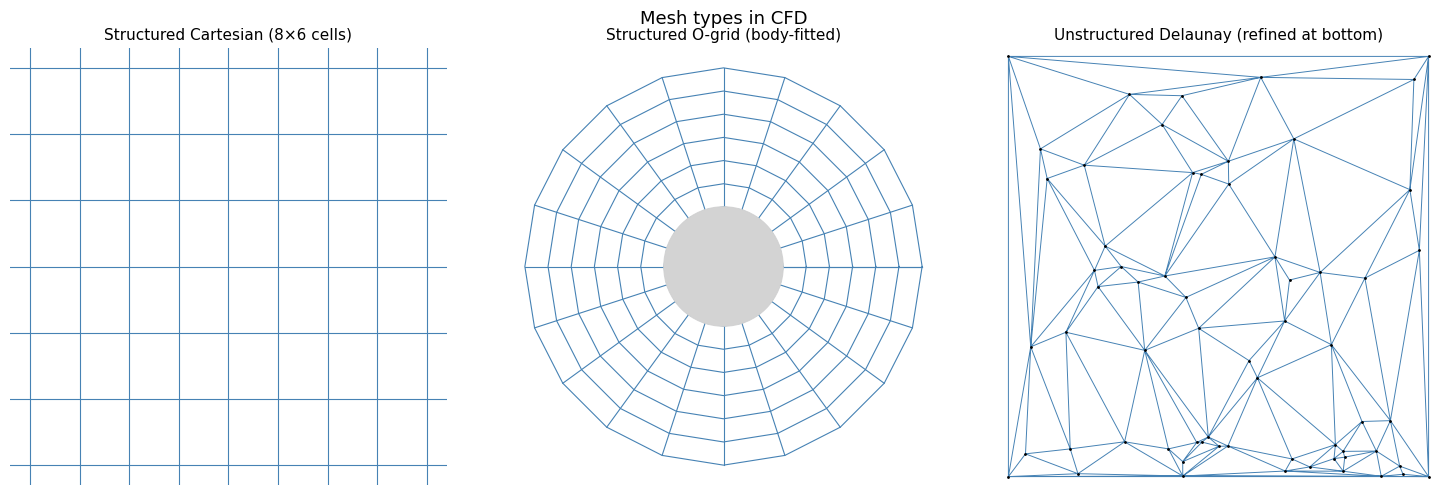

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Compare structured vs unstructured meshes visually

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Structured Cartesian grid ---
nx, ny = 8, 6
x_s = np.linspace(0, 1, nx+1)
y_s = np.linspace(0, 1, ny+1)
for xi in x_s:
    axes[0].axvline(xi, color='steelblue', linewidth=0.8)
for yi in y_s:
    axes[0].axhline(yi, color='steelblue', linewidth=0.8)
axes[0].set_xlim(-0.05, 1.05); axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title(f'Structured Cartesian ({nx}×{ny} cells)', fontsize=11)
axes[0].set_aspect('equal'); axes[0].axis('off')

# --- Body-fitted structured grid (O-grid around circle) ---
nr, ntheta = 6, 20
r_vals = np.linspace(0.3, 1.0, nr+1)
theta  = np.linspace(0, 2*np.pi, ntheta+1)
for r in r_vals:
    axes[1].plot(r*np.cos(theta), r*np.sin(theta), 'steelblue', linewidth=0.8)
for th in theta:
    r_line = np.linspace(r_vals[0], r_vals[-1], 50)
    axes[1].plot(r_line*np.cos(th), r_line*np.sin(th), 'steelblue', linewidth=0.8)
circle = plt.Circle((0,0), r_vals[0], color='lightgray', zorder=5)
axes[1].add_patch(circle)
axes[1].set_xlim(-1.1, 1.1); axes[1].set_ylim(-1.1, 1.1)
axes[1].set_title('Structured O-grid (body-fitted)', fontsize=11)
axes[1].set_aspect('equal'); axes[1].axis('off')

# --- Triangulated unstructured-like mesh (Delaunay) ---
from scipy.spatial import Delaunay
np.random.seed(7)
# Cluster more points near bottom (refinement)
pts_bulk = np.random.rand(40, 2)
pts_fine = np.column_stack([np.random.rand(20), 0.1*np.random.rand(20)])
pts = np.vstack([pts_bulk, pts_fine,
                 [[0,0],[1,0],[0,1],[1,1]]])  # corners
tri = Delaunay(pts)
# Pass color as keyword — triplot does not accept a format string
axes[2].triplot(pts[:,0], pts[:,1], tri.simplices, color='steelblue', linewidth=0.7)
axes[2].plot(pts[:,0], pts[:,1], 'k.', markersize=2)
axes[2].set_title('Unstructured Delaunay (refined at bottom)', fontsize=11)
axes[2].set_xlim(-0.02, 1.02); axes[2].set_ylim(-0.02, 1.02)
axes[2].set_aspect('equal'); axes[2].axis('off')

plt.suptitle('Mesh types in CFD', fontsize=13)
plt.tight_layout()
plt.show()

In [3]:
# y+ calculator: first cell height for a flat-plate boundary layer

def first_cell_height(Re_L, L, nu, y_plus_target):
    """
    Estimate first cell height to achieve target y+.
    Uses flat-plate turbulent BL correlation: Cf = 0.027*Re^(-1/7)
    """
    U_inf = Re_L * nu / L
    Cf    = 0.027 * Re_L**(-1/7)
    tau_w = 0.5 * 1.0 * U_inf**2 * Cf  # rho=1
    u_tau = np.sqrt(tau_w)
    y1    = y_plus_target * nu / u_tau
    return y1, u_tau, Cf

print("First cell height calculator")
print(f"{'Case':<30} {'Re':<10} {'y+':>6} {'y1 (m)':>12} {'u_tau':>10} {'Cf':>10}")
print("-" * 80)

cases = [
    ("Aircraft wing (10m chord)", 1e7, 10.0, 1.5e-5, 1),
    ("Aircraft wing (10m chord)", 1e7, 10.0, 1.5e-5, 30),
    ("Car (4m length)",          5e6,  4.0, 1.5e-5, 1),
    ("Car (4m length)",          5e6,  4.0, 1.5e-5, 50),
    ("Pipe (1m, water)",         1e5,  1.0, 1e-6,   1),
]

for name, Re, L, nu, y_plus in cases:
    y1, u_tau, Cf = first_cell_height(Re, L, nu, y_plus)
    print(f"{name:<30} {Re:<10.0e} {y_plus:>6.0f} {y1:>12.4e} {u_tau:>10.4f} {Cf:>10.6f}")

print("\nNote: y+=1 requires much finer cells than y+=50 (wall function).")

First cell height calculator
Case                           Re             y+       y1 (m)      u_tau         Cf
--------------------------------------------------------------------------------
Aircraft wing (10m chord)      1e+07           1   2.7217e-05     0.5511   0.002700
Aircraft wing (10m chord)      1e+07          30   8.1650e-04     0.5511   0.002700
Car (4m length)                5e+06           1   2.0721e-05     0.7239   0.002981
Car (4m length)                5e+06          50   1.0361e-03     0.7239   0.002981
Pipe (1m, water)               1e+05           1   1.9587e-04     0.0051   0.005213

Note: y+=1 requires much finer cells than y+=50 (wall function).


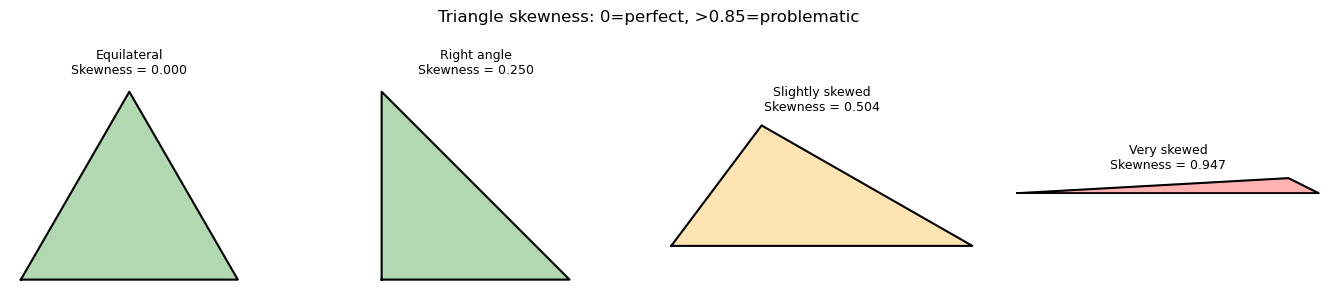

In [4]:
# Mesh quality: skewness of a triangle

def triangle_skewness(p1, p2, p3):
    """Equiangle skewness of a triangle."""
    # Sides
    a = np.linalg.norm(p2 - p3)
    b = np.linalg.norm(p1 - p3)
    c = np.linalg.norm(p1 - p2)
    # Angles via law of cosines
    angles = []
    for opp, adj1, adj2 in [(a, b, c), (b, a, c), (c, a, b)]:
        cos_angle = (adj1**2 + adj2**2 - opp**2) / (2*adj1*adj2 + 1e-12)
        angles.append(np.degrees(np.arccos(np.clip(cos_angle, -1, 1))))
    eq_angle = 60.0  # equilateral triangle
    theta_max = max(angles)
    theta_min = min(angles)
    skewness = max((theta_max - eq_angle)/(180 - eq_angle),
                   (eq_angle - theta_min)/eq_angle)
    return skewness, angles

triangles = [
    ("Equilateral",     np.array([0,0.0]), np.array([1,0.0]), np.array([0.5, 0.866])),
    ("Right angle",     np.array([0,0.0]), np.array([1,0.0]), np.array([0.0, 1.0])),
    ("Slightly skewed", np.array([0,0.0]), np.array([1,0.0]), np.array([0.3, 0.4])),
    ("Very skewed",     np.array([0,0.0]), np.array([1,0.0]), np.array([0.9, 0.05])),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (name, p1, p2, p3) in zip(axes, triangles):
    sk, angs = triangle_skewness(p1, p2, p3)
    pts = np.array([p1, p2, p3, p1])
    color = 'green' if sk < 0.5 else 'orange' if sk < 0.8 else 'red'
    ax.fill(pts[:,0], pts[:,1], alpha=0.3, color=color)
    ax.plot(pts[:,0], pts[:,1], 'k-', linewidth=1.5)
    ax.set_title(f'{name}\nSkewness = {sk:.3f}', fontsize=9)
    ax.set_aspect('equal')
    ax.axis('off')

plt.suptitle('Triangle skewness: 0=perfect, >0.85=problematic', fontsize=12)
plt.tight_layout()
plt.show()

## Key Takeaways

- Structured meshes: fast and accurate for simple geometries. Unstructured: flexible for complex shapes.
- Mesh quality metrics: skewness ($< 0.85$), aspect ratio, orthogonality ($< 70°$).
- $y^+$ determines near-wall cell height: $y^+ \approx 1$ for resolved wall, $y^+ \approx 30$–100 for wall functions.
- Mesh refinement should follow flow gradients — fine in BLs and shear layers, coarse in bulk flow.
- Always run a mesh convergence study: solve on three meshes (coarse, medium, fine) and check solution change.

---

**Next**: Lesson 3.4 — Higher-Order Schemes: QUICK, TVD limiters, MUSCL.
